# Part 2. RBC news scarping and parsing + sentiment analysis


## Our goal

The main purpose of this part is to collect a dataset of news articles from the RBC website (rbc.ru ) for 9 large Russian public companies to further analyze the impact of the news background on stock prices on the Moscow Stock Exchange (MOEX)

We have selected the following companies: Gazprom (GAZP), Lukoil (LKOH), Rosneft (ROSN), Sberbank (SBER), MTS (MTSS), Norilsk Nickel (GMKN), Magnit (MGNT), Alrosa (ALRS) and VTB (VTBR)

## Step 1. Tools and libraries used

Before going into scrаping we shoukd think about which libraries will be useful for us and which of them should be downloaded. As our goal is not only to get links from РБК, but also make a sentiment analysis, we will need some special model in addition to selenium, beautfil soup, which will help us to solve the problen of how news influences stock prices. Due to some problems with dowloading dostoevski, we find a new model seara/rubert-tiny2-russian-sentiment https://huggingface.co/seara/rubert-tiny2-russian-sentiment (and on this site we find HOW to download it). Also one of the main pluses of this model is that it trained on russian texts and it will be super usefull for РБК. This model will return the persentage of how negative, positive and neutral the news are and its perfectly suitable for us

Library beautiful soup is basic since its parsing html and transform raw html in a convinient structure for a searching (like a tree). After selenium has downloaded page we should extract title, text and data and soup will find elements by teg class or atriute  https://www.crummy.com/software/BeautifulSoup/bs4/doc/ https://habr.com/ru/articles/986284/

In [1]:
!pip install selenium
!pip install webdriver-manager
!pip install beautifulsoup4
!pip install pandas
!pip install lxml
!pip install requests
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 10.4 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 84.7 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


https://stackoverflow.com/questions/70955307/how-to-install-google-chrome-in-a-docker-container

link for !wget (how we install chrome)
it is neccessary for selenium (mаnage)

In [2]:
!apt-get update -qq
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get install -y ./google-chrome-stable_current_amd64.deb

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'google-chrome-stable' instead of './google-chrome-stable_current_amd64.deb'
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libatk-bridge2.0-0 libatk1.0-0
  libatk1.0-data libatspi2.0-0 libvulkan1 libxcomposite1 libxtst6
  mesa-vulkan-drivers session-migration
The following NEW packages will be installed:
  at-spi2-core google-chrome-stable gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libvulkan1
  libxcomposite1 libxtst6 mesa-vulkan-drivers session-migration
0 upgraded, 12 newly installed, 0 to remove and 10 not upgraded.
Need to get 11.2 MB/139 MB of archives.
After this operation, 467 MB of addition

In [5]:
import time #слип
import re #regex
import pandas as pd
import logging
import os #work with oper system (files)

from datetime import datetime
from selenium import webdriver as wd   #открывает сам браузер
from selenium.webdriver.chrome.service import Service  #запускаем хром драйвер
from selenium.webdriver.chrome.options import Options  #настройки(чтобы не было видно окна и тп)
from selenium.webdriver.common.by import By   #поиск элементов через by
from webdriver_manager.chrome import ChromeDriverManager #нужн версия хрома
from bs4 import BeautifulSoup
from transformers import pipeline #для тональности

https://stackoverflow.com/questions/60296873/sessionnotcreatedexception-message-session-not-created-this-version-of-chrome about chrome driver

creating papka https://sky.pro/wiki/media/avtomaticheskoe-sozdanie-direktorij-pri-rabote-s-fajlami-v-python/?ysclid=mn0gkq6utk504264426

In [6]:
os.makedirs('data', exist_ok=True) #экзист обрабатыв сущ директории

In [7]:
logging.basicConfig(
    level=logging.INFO,
    format = "%(asctime)s - %(levelname)s - %(funcName)s: %(lineno)d - %(message)s",
    datefmt='%Y-%m-%d %H:%M:%S',
    force=True,
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

links of the format https://tproger.ru/articles/shpargalka-po-logirovaniju-na-python

choose level Info (20): этот уровень предназначен для вывода данных о фрагментах кода, работающих так, как ожидается. - https://habr.com/ru/companies/wunderfund/articles/683880/

datefmt (str) – A format string for the date/time portion of the logged output. https://docs.python.org/3/library/logging.html#:~:text=datefmt%20(str)%20%E2%80%93%20A%20format%20string%20for%20the%20date/time%20portion%20of%20the%20logged%20output.%20If%20not%20specified%2C%20the%20default%20described%20in%20formatTime()%20is%20used.

in colab we MUST put force=True to be sure that settings apllyed and everything works good https://docs.python.org/3/library/logging.html

from habr we found that logging.getLogger(name) return logger with given name if it exists and if not it creates a logger with the given name
https://habr.com/ru/companies/wunderfund/articles/683880/

StreamHandler to see logger progresss
https://docs.python.org/3/library/logging.handlers.html#logging.StreamHandler:~:text=The%20StreamHandler%20class%2C%20located%20in%20the%20core%20logging%20package%2C%20sends%20logging%20output%20to%20streams%20such%20as%20sys.stdout%2C%20sys.stderr%20or%20any%20file%2Dlike%20object%20(or%2C%20more%20precisely%2C%20any%20object%20which%20supports%20write()%20and%20flush()%20methods).


In [9]:
vibe = pipeline("text-classification", model="seara/rubert-tiny2-russian-sentiment")

2026-03-22 09:56:26 - INFO - _send_single_request: 1025 - HTTP Request: HEAD https://huggingface.co/seara/rubert-tiny2-russian-sentiment/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-22 09:56:26 - WARNING - _warn_on_warning_headers: 916 - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-03-22 09:56:26 - INFO - _send_single_request: 1025 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/seara/rubert-tiny2-russian-sentiment/ad9be38671d4444945734cce7cdaadacc5002cc4/config.json "HTTP/1.1 200 OK"
2026-03-22 09:56:27 - INFO - _send_single_request: 1025 - HTTP Request: HEAD https://huggingface.co/seara/rubert-tiny2-russian-sentiment/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-22 09:56:27 - INFO - _send_single_request: 1025 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/seara/rubert-tiny2-russian-sentiment/ad9be38671d

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: seara/rubert-tiny2-russian-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-22 09:56:27 - INFO - _send_single_request: 1025 - HTTP Request: GET https://huggingface.co/api/models/seara/rubert-tiny2-russian-sentiment/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-22 09:56:27 - INFO - _send_single_request: 1025 - HTTP Request: GET https://huggingface.co/api/models/seara/rubert-tiny2-russian-sentiment/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


this is our model and it was downloaded from here https://huggingface.co/seara/rubert-tiny2-russian-sentiment


In [10]:
companies = {
    'GAZP': 'Газпром' ,
    'LKOH' :'Лукойл',
    'ROSN':'Роснефть',
   'SBER': 'Сбербанк',
    'MTSS':'МТС',
    'GMKN' :'Норникель',
    'MGNT':'Магнит',
    'ALRS':'Алроса',
    'VTBR': 'ВТБ'
}

from_date = '2018-01-01'
to_date   = '2026-12-31'
num = 5 #initially was 1500, bur for tests 5

and below we officially create function for our browser

In [16]:
def sozdaemd():
  nastroyki = Options()
  nastroyki.add_argument('--headless=new') #без граф окна
  nastroyki.add_argument('--no-sandbox') #для повышения стабильности работы колаба
  nastroyki.add_argument('--disable-dev-shm-usage') #economim
  s = Service(ChromeDriverManager().install())
  driver = wd.Chrome(service=s, options=nastroyki) #optiond based on nastroyki above  chrome will not open as a wondow
  return driver

about using options https://www.selenium.dev/documentation/webdriver/browsers/chrome/



from webdriver_manager.chrome import ChromeDriverManager

driver = webdriver.Chrome(ChromeDriverManager().install())


https://stackoverflow.com/questions/60296873/sessionnotcreatedexception-message-session-not-created-this-version-of-chrome

info of creating driver

--headless=new oppen chrome without graphical windonm (if we not put this parametr the window of chrome will be open and our macbooks will be burned)
https://developer.chrome.com/docs/chromium/headless?hl=ru

no sandbox for better perfom https://timeweb.cloud/tutorials/python/selenium-parsing-dinamicheskih-sajtov


--disable-dev-shm-usage not approve chrome to use temporary memrory. colab has small
https://dev.to/bailon/how-to-set-up-selenium-as-a-linux-daemon-with-systemd-4bdc


In [15]:
def sobiraems(driver, ticker, from_date, to_date, maxy=1500):
  u = f'https://www.rbc.ru/search/?query={ticker}&dateFrom={from_date}&dateTo={to_date}'
  driver.get(u)
  time.sleep(3)
  linki = set()

  while len(linki) < maxy:
    nashli = driver.find_elements(By.CLASS_NAME, 'js-search-item-link')
    for a in nashli:
      linki.add(a.get_attribute('href'))
    driver.execute_script('window.scrollTo(0, 9999999);') #пролистывание
    time.sleep(3)
  return list(linki)[:maxy] #берем первые макси

about why we use execute script

https://happypython.ru/2022/11/27/selenium-chromedriver-find-elements/#:~:text=%D0%9F%D1%80%D0%BE%D0%BB%D0%B8%D1%81%D1%82%D1%8B%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5%20%D0%BF%D1%80%D0%BE%D0%B8%D1%81%D1%85%D0%BE%D0%B4%D0%B8%D1%82%20%D0%B1%D0%BB%D0%B0%D0%B3%D0%BE%D0%B4%D0%B0%D1%80%D1%8F%20%D0%B2%D1%8B%D0%BF%D0%BE%D0%BB%D0%BD%D0%B5%D0%BD%D0%B8%D1%8E%20%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D0%B0%20execute_script

find_elements
https://ya.ru/neurum/c/nauka-i-obrazovanie/q/chem_otlichaetsya_metod_findelement_ot_findelements_84a7b1d2

metods of selenium https://www.geeksforgeeks.org/python/get_attribute-element-method-selenium-python/

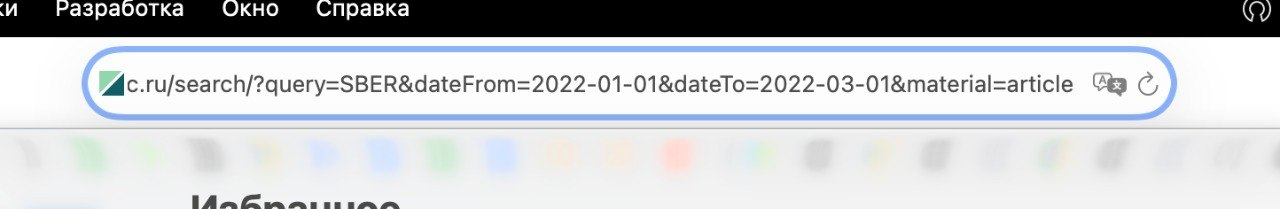

we work wit the link above and put tikeri and daty from there

and now we need to parse our link

In [17]:
def parsiruem(driver, url, ticker):
  driver.get(url)
  time.sleep(3)
  s = BeautifulSoup(driver.page_source, 'lxml')

  zagolovok = s.find('h1', class_='article__header__title-in')
  if zagolovok:
    title = zagolovok.get_text()
  else:
    title = ''

  vremya = s.find('time', class_='article__header__date')
  if vremya:
    published_at = vremya.get('datetime')
  else:
    published_at = None

  opisanie = s.find('div', class_='article__text')
  textp = []
  if opisanie:
    for p in opisanie.find_all('p'):
      textp.append(p.get_text())
  text = ' '.join(textp)

  categorya = s.find('a', class_='article__header__category')
  if categorya:
    c = categorya.get_text()
  else:
    c = 'Не определена'

  n = url.strip('/')  #убираем / в конце
  n = n.split('/')[-1]  #последняя часть url
  n = n.replace('.shtml', '')  #убираем shtml

  return {
      'news_id':n,
      'ticker':ticker,
      'url':url,
      'title':title,
      'published_at':published_at,
      'text' : text,
      'category':c,
    }

lxml in bs we choose because we can parse much more faster html pages than common html.parser (which was discussed on lectures) (we have 1500 links!!!!), informagion was found there https://beautiful-soup.readthedocs.io/en/latest/

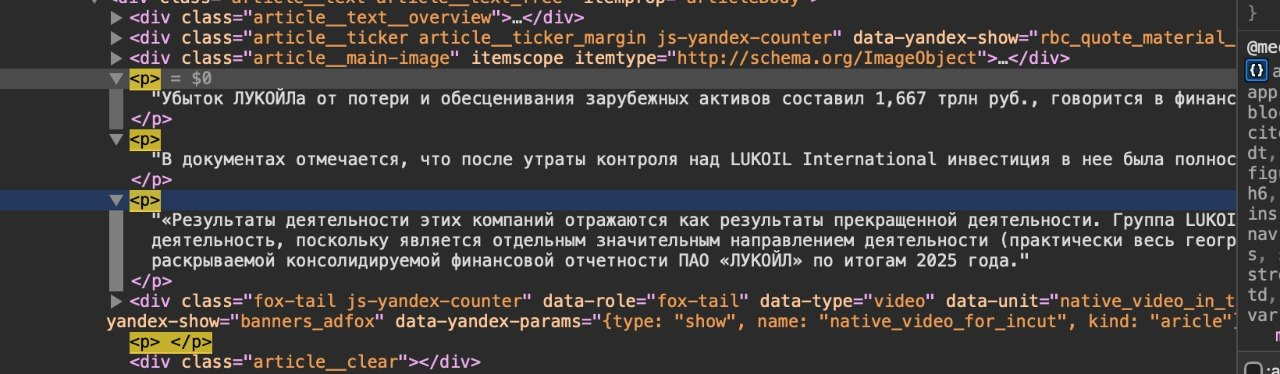

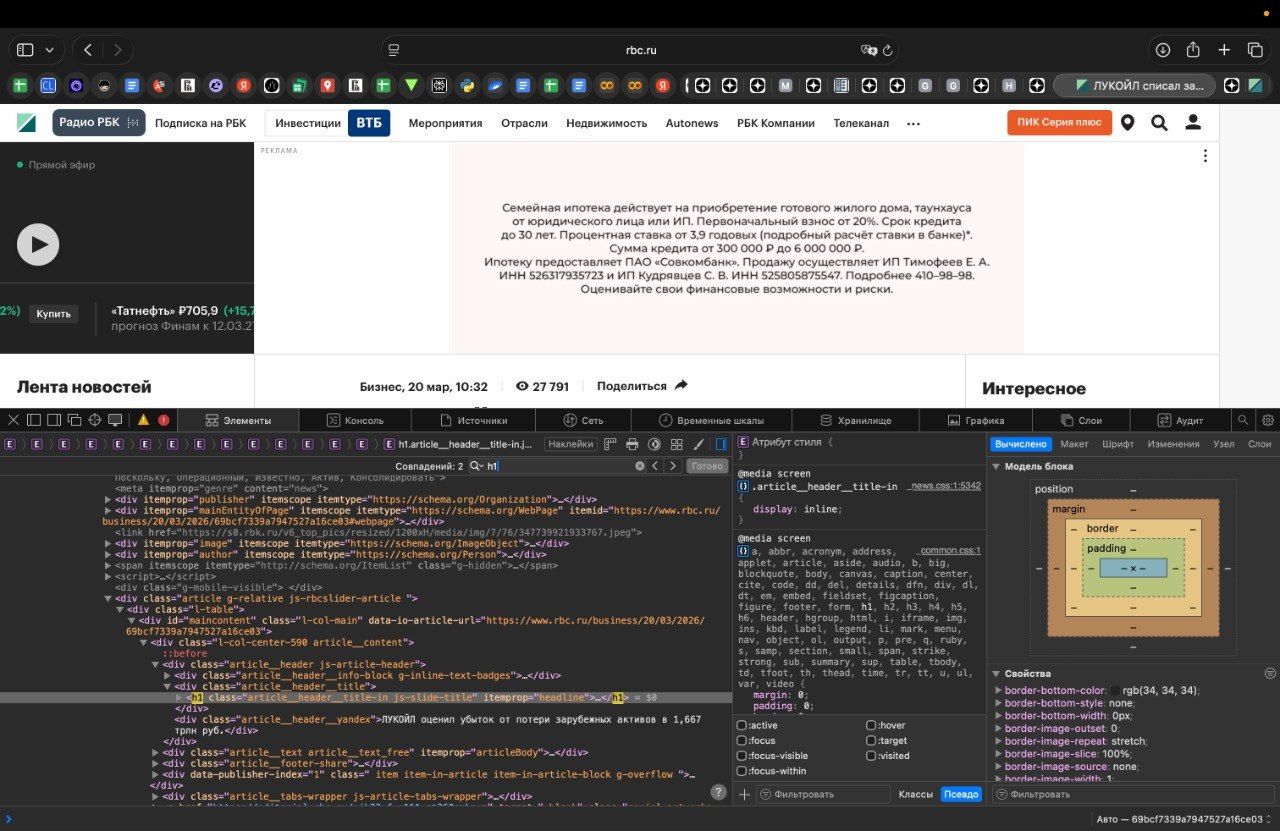

In [18]:
def chistimt(t):
  if not t:
    return ''
  t = re.sub(r'<[^>]+>','', t) #чистим хтмл
  t = re.sub(r'https?://\S+', '', t) #ссылки
  t = re.sub(r'\s{2,}', ' ', t)  #лишние пробелы
  return t.strip()

fron seminar 13 RegEx all info
re.sub(pattern, repl, string) - Replaces all occurrences of the pattern in the string with a replacement string and returns the modified string.

we find out that sometimes there are extra probely in the begining and end so we use strip
https://ru.hexlet.io/qna/python/questions/chto-delaet-funktsiya-strip-v-python

In [19]:
def chistimd(dati):
  if not dati:
    return None
  s = str(dati)
  s = re.sub(r'\+\d{2}:\d{2}$', '', s)
  s = re.sub(r'Z$', '', s)
  s = s.strip() #также убираем лишн пробелы
  #пробуем разные форматы
  try:
    d = datetime.strptime(s, '%Y-%m-%dT%H:%M:%S')
  except:
      try:
          d = datetime.strptime(s, '%Y-%m-%d %H:%M:%S')
      except:
          try:
              d = datetime.strptime(s, '%d.%m.%Y %H:%M')
          except:
              try:
                  d = datetime.strptime(s, '%d.%m.%Y')
              except:
                  return s  #если вообще не распарсилось
  return d.strftime('%Y-%m-%d %H:%M:%S')

https://skillbox.ru/media/code/datetime-python/ using datetime

now its time for understanting the vibe of the text inside article thats why we create function nastroenie

In [21]:
def nastroenie(t):
  if not t or len(t) < 10:
    return {'positive':None, 'negative':None, 'neutral':None}
  res = vibe(t[:512])[0] #модель не принимает больше
  label  = res['label']
  score  = round(res['score'], 4)
  other  = round((1-score)/2, 4)
  if label == 'positive':
    return {'positive': score, 'negative': other, 'neutral': other}
  elif label == 'negative':
    return {'positive': other, 'negative': score, 'neutral': other}
  else:
    return {'positive': other, 'negative': other, 'neutral': score}


https://huggingface.co/learn/llm-course/ru/chapter7/3

In [22]:
def finalochka(ticker, company_name, driver):
  logger.info(f'Parsing {company_name} is starting')
  l = sobiraems(driver, ticker, from_date, to_date, num)
  a = []
  for url in l:
    r = parsiruem(driver, url, ticker)
    if r:
      r['text'], r['title'] = chistimt(r['text']), chistimt(r['title'])
      r['published_at'] = chistimd(r['published_at'])
      realvibe = nastroenie(r['text'])
      r['sentiment_positive'] = realvibe['positive']
      r['sentiment_negative'] = realvibe['negative']
      r['sentiment_neutral']  = realvibe['neutral']
      a.append(r)
    time.sleep(2)

  df = pd.DataFrame(a)
  df.to_csv(f'data/rbc_{ticker}.csv', index=False, encoding='utf-8-sig')
  return df

https://habr.com/ru/companies/wunderfund/articles/683880/ for logger

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html index false for not writing 0 1 2 3 near rows

hooray we finally did it

In [32]:
driver = sozdaemd()

2026-03-22 11:54:00 - INFO - log: 11 - ====== WebDriver manager ======
2026-03-22 11:54:00 - INFO - log: 11 - Get LATEST chromedriver version for google-chrome
2026-03-22 11:54:00 - INFO - log: 11 - Get LATEST chromedriver version for google-chrome
2026-03-22 11:54:00 - INFO - log: 11 - Driver [/root/.wdm/drivers/chromedriver/linux64/146.0.7680.153/chromedriver-linux64/chromedriver] found in cache


In [39]:
ROSN = finalochka('ROSN', 'Роснефть', driver)
print(len(ROSN ))

2026-03-22 11:59:41 - INFO - finalochka: 2 - Parsing Роснефть is starting


5


In [40]:
ROSN.head(5)

,news_id,ticker,url,title,published_at,text,category,sentiment_positive,sentiment_negative,sentiment_neutral
0,68066c019a79473d78b91e42,ROSN,https://pro.rbc.ru/demo/68066c019a79473d78b91e42,Удар по карманам: какие акции легче перенесут ...,None,,Не определена,NaN,NaN,NaN
1,6850551b9a794751b0a00ff7,ROSN,https://pro.rbc.ru/demo/6850551b9a794751b0a00ff7,"«Нефть по $90, доллар по ₽76»: cценарии конфли...",None,,Не определена,NaN,NaN,NaN
2,6879d1739a7947aadefe14ad,ROSN,https://www.rbc.ru/quote/news/article/6879d173...,"Дивидендный гэп «Сбера», «Роснефти» и «Аэрофло...",2025-07-18 09:02:22,"В пятницу, 18 июля, от дивидендов очистятся ак...",События дня,0.0665,0.0665,0.8669
3,654e08ac9a7947070a333968,ROSN,https://www.rbc.ru/quote/news/article/654e08ac...,Совет директоров «Роснефти» рекомендовал дивид...,2024-11-08 22:26:56,Совет директоров «Роснефти» (ROSN) рекомендова...,Новости,0.0540,0.0540,0.8920
4,6731829d9a7947572a49bc24,ROSN,https://www.rbc.ru/quote/news/article/6731829d...,"Индекс Мосбиржи, дивиденды «Роснефти», акции «...",2024-11-11 09:10:16,"Индекс Мосбиржи в пятницу, 8 ноября, по итогам...",События дня,0.0916,0.0916,0.8169
